# Setup aid: pandas, plotting, and statsmodels basics

**This is a short setup aid, not a demonstration of the full difference-in-differences analysis required for the project.** It uses a small, unrelated example to illustrate basic pandas, plotting, and statsmodels syntax. 

Students are expected to design, write, validate, and interpret their own project analysis.

- The example concerns an **unrelated store-signage rollout**.
- It **does not use the main project data**.

It is a small **two-group, pre/post example** (a few months grouped into pre- and post-rollout periods) used only to show mechanics.

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import statsmodels.formula.api as smf

In [3]:
# A tiny, made-up store-signage example. Two stores, six months each (12 rows).
# One comparison store and one treated store; signage goes up at month 4.
df = pd.DataFrame(
    {
        "month": [1, 2, 3, 4, 5, 6, 1, 2, 3, 4, 5, 6],
        "store": ["Comparison"] * 6 + ["Treated"] * 6,
        "sales": [100, 102, 104, 106, 108, 110, 120, 122, 124, 130, 133, 136],
        "treated": [0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1],
        "post": [0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1],
    }
)
df

,month,store,sales,treated,post
0,1,Comparison,100,0,0
1,2,Comparison,102,0,0
2,3,Comparison,104,0,0
3,4,Comparison,106,0,1
4,5,Comparison,108,0,1
5,6,Comparison,110,0,1
6,1,Treated,120,1,0
7,2,Treated,122,1,0
8,3,Treated,124,1,0
9,4,Treated,130,1,1


## Inspect the data

Each row is one store in one month.

- `month` is the time period
- `store` is the group
- `sales` is the outcome
- `treated` marks the store that received signage
- `post` marks months on or after the rollout.

Difference-in-differences compares how the treated group changes relative to how the comparison group changes.

In [4]:
df.info()
df.groupby(["store", "post"])[
    "sales"
].mean()  # group by store and period and see mean of sales

<class 'pandas.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   month    12 non-null     int64
 1   store    12 non-null     str  
 2   sales    12 non-null     int64
 3   treated  12 non-null     int64
 4   post     12 non-null     int64
dtypes: int64(4), str(1)
memory usage: 612.0 bytes


store       post
Comparison  0       102.0
            1       108.0
Treated     0       122.0
            1       133.0
Name: sales, dtype: float64

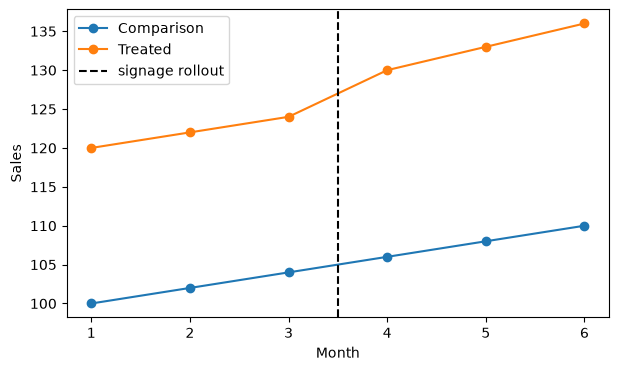

In [ ]:
# Plot one line per group, with a vertical marker at the rollout.
fig, ax = plt.subplots(figsize=(7, 4))
for store, g in df.groupby("store"):
    ax.plot(g["month"], g["sales"], marker="o", label=store)
ax.axvline(3.5, color="black", ls="--", label="signage rollout")
ax.set_xlabel("Month")
ax.set_ylabel("Sales")
ax.legend()
plt.show()

We can visually support that both stores behave similarly in the pre-treatment period (< month 4) 

## Using OLS in statsmodels: a simple pre-trend check

Now we introduce the regression syntax used for the rest of the notebook. 

A statsmodels formula has the structure `outcome ~ predictors`, and a model is set up and fit with `smf.ols(formula, data=df).fit()`.

For the pre-trend check we write the predictors out directly: `sales ~ month + treated + month:treated`. Here `month:treated` is the interaction between month and the treated indicator. We fit this model on the **pre-rollout rows only**, as one supporting check of slope similarity to check for "parallel trends". If we see the coefficient on the interaction term equal 0, i.e param of `month:treated = 0`,  it would support similar pre-trends because:

- `month` is the comparison group's fitted pre-rollout slope;
- the treated group's fitted slope is `month + month:treated`;
- so `month:treated` is the difference between the two groups' pre-rollout slopes;
- a value of zero means their fitted linear pre-rollout slopes are equal.

This is **supporting evidence only** — it does **not** prove that parallel trends hold, or that the groups would have stayed parallel after rollout.

In [9]:
# Compare pre-rollout slopes using only the pre-period rows.
pre = df[df["post"] == 0]

pretrend_model = smf.ols(
    "sales ~ month + treated + month:treated",
    data=pre,
).fit()  # fit the model on pre-rollout data only

pretrend_model.params[["month", "month:treated"]].round(
    3
)  # print model params

month            2.0
month:treated    0.0
dtype: float64

## A basic pre/post interaction

We now apply the same syntax to the **full** toy dataset, again writing the predictors out directly: `sales ~ treated + post + treated:post`. The `treated:post` term is the interaction in this basic pre/post setup. We fit the model and look only at its coefficients and confidence intervals.

In [10]:
model = smf.ols(
    "sales ~ treated + post + treated:post",
    data=df,
).fit()  # fit model on all data

print(model.params)
print()
print(model.conf_int())  # 95% Confidence Intervals

Intercept       102.0
treated          20.0
post              6.0
treated:post      5.0
dtype: float64

                      0           1
Intercept     98.949443  105.050557
treated       15.685861   24.314139
post           1.685861   10.314139
treated:post  -1.101113   11.101113


## Reading the result

The `treated:post` coefficient is the difference-in-differences estimate: in this simple two-group, pre/post regression it estimates the signage effect at about **+5 sales units**. It is the extra change in the treated store's sales, on and after rollout, beyond the change seen in the comparison store over the same period.

Two cautions, even in this toy example:

- The 95% confidence interval for `treated:post` runs from roughly **−1.1 to +11.1**. Because it includes zero, we could **not** distinguish this estimate from "no effect" at the usual threshold — the point estimate is positive, but imprecise.
- This is made-up data with two stores and six months. A real analysis needs a justified comparison group, a credible parallel-trends argument, and sensitivity checks before any effect estimate should be believed.

## What this notebook does and does not cover

This notebook only demonstrates basic data setup, plotting, and statsmodels formula syntax. The project requires you to choose and justify a comparison group, assess the credibility of the design, write the appropriate analysis, perform sensitivity checks, and communicate the result.

It **does not** cover:

- the full project DiD design;
- fixed effects;
- control selection;
- anticipation;
- concurrent shocks;
- robustness analysis;
- the main project answer.

We will explore these fully during the Fall 2026 challenge.